# Notebook 04: Information Gain & Complexity Analysis

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid")

data_path = Path("/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_tables")
fig_path = Path("/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/04_information_gain")
fig_path.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path / "results_seed_level.csv")
df.head()


,dataset_variant,config_name,run_id,combo_id,val_strategy,seed,threshold,model_key,model_class,model_params,...,roc_auc,pr_auc,mcc,brier,accuracy,balanced_accuracy,precision,recall,f1,loo_metric_source
0,IMPUTED,config_kfold,20260202_032849,1,kfold,4.781633e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.803034,0.659453,0.411356,0.151723,0.78750,0.681884,0.658889,0.450000,0.507512,reported_fold_mean
1,IMPUTED,config_kfold,20260202_032849,2,kfold,1.122457e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.820018,0.680020,0.423810,0.148044,0.78750,0.676510,0.707302,0.430556,0.518162,reported_fold_mean
2,IMPUTED,config_kfold,20260202_032849,3,kfold,1.988882e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.825377,0.663983,0.462220,0.143389,0.80000,0.700302,0.732698,0.477778,0.545664,reported_fold_mean
3,IMPUTED,config_kfold,20260202_032849,4,kfold,1.648071e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.814538,0.679425,0.481473,0.148196,0.80625,0.717995,0.697619,0.522222,0.595462,reported_fold_mean
4,IMPUTED,config_kfold,20260202_032849,5,kfold,2.013804e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.801283,0.652545,0.335151,0.154048,0.75625,0.649577,0.586508,0.411111,0.457560,reported_fold_mean


In [2]:

def compute_complexity(row):
    complexity = 0
    if row["scaler"] != "none":
        complexity += 1
    if row["resampling"] != "none":
        complexity += 1
    if row["pca"] != "none":
        complexity += 1
    if row["model_class"] not in ["LogisticRegression", "GaussianNB"]:
        complexity += 1
    return complexity

df["complexity_score"] = df.apply(compute_complexity, axis=1)
df["complexity_score"].value_counts()


complexity_score
4    1318059
3     618185
2      62927
1       1417
Name: count, dtype: int64

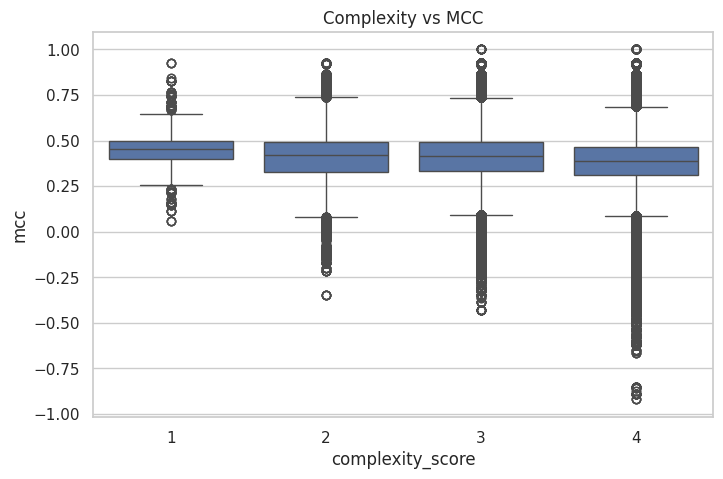

In [3]:

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="complexity_score", y="mcc")
plt.title("Complexity vs MCC")
plt.savefig(fig_path / "complexity_vs_mcc.png", dpi=300)
plt.show()


In [4]:

complexity_stats = df.groupby("complexity_score")["mcc"].agg(["mean","std","count"])
complexity_stats


,mean,std,count
complexity_score,,,
1,0.451532,0.115016,1417
2,0.403909,0.153271,62895
3,0.408659,0.143139,618077
4,0.383047,0.137693,1318020


In [9]:
baseline = df[
    (df["model_class"] == "LogisticRegression") &
    (df["scaler"] == "none") &
    (df["resampling"] == "none") &
    (df["pca"] == "off")
]

print(baseline.shape)

baseline_mean = baseline["mcc"].mean()
df["delta_mcc_vs_baseline"] = df["mcc"] - baseline_mean

baseline_mean


(984, 36)


np.float64(0.4671796429251973)

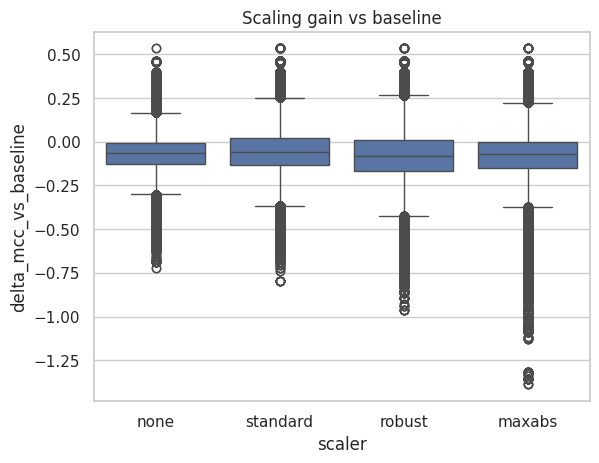

In [10]:

sns.boxplot(data=df, x="scaler", y="delta_mcc_vs_baseline")
plt.title("Scaling gain vs baseline")
plt.savefig(fig_path / "scaling_gain.png", dpi=300)
plt.show()


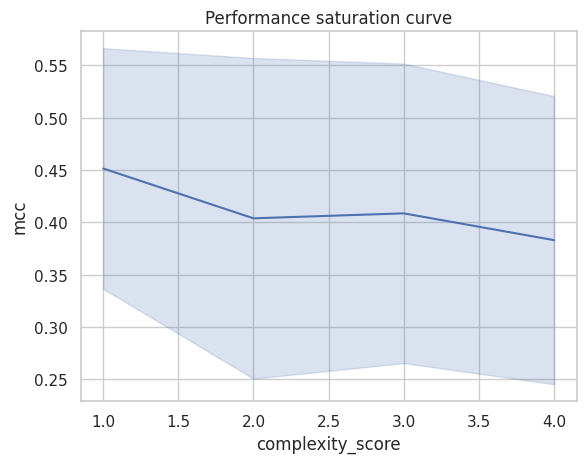

In [11]:

sns.lineplot(data=df, x="complexity_score", y="mcc", estimator="mean", errorbar="sd")
plt.title("Performance saturation curve")
plt.savefig(fig_path / "saturation_curve.png", dpi=300)
plt.show()


In [12]:

robustness = df.groupby("complexity_score")["mcc"].agg(["mean","std"])
robustness["stability_ratio"] = robustness["std"] / robustness["mean"]
robustness


,mean,std,stability_ratio
complexity_score,,,
1,0.451532,0.115016,0.254723
2,0.403909,0.153271,0.379470
3,0.408659,0.143139,0.350265
4,0.383047,0.137693,0.359468


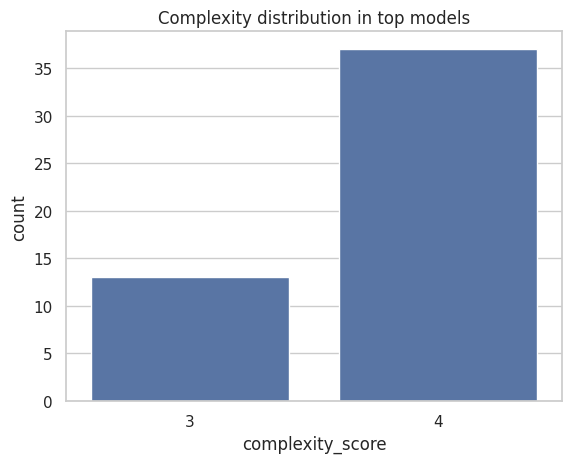

In [13]:

top_df = df.sort_values("mcc", ascending=False).head(50)
sns.countplot(data=top_df, x="complexity_score")
plt.title("Complexity distribution in top models")
plt.savefig(fig_path / "top_complexity.png", dpi=300)
plt.show()
